# Tutorial – Session 2

## Diskrete fordelinger: Uniform, Bernoulli og Binomial
### Teori, Python (SciPy) og WolframAlpha

I denne tutorial kobler vi teorien fra Ross (Kapitel 4 & 5) til praktiske beregninger.
Vi arbejder systematisk med tre fundamentale diskrete fordelinger:

1. **Diskret Uniform** (f.eks. terningekast)
2. **Bernoulli** (ét forsøg: succes/fiasko)
3. **Binomial** (antal succeser i $n$ forsøg)

Vi lærer at beregne **PMF**, **CDF**, **Middelværdi (Expected Value)** og **Varians** i både Python og WolframAlpha.

---

## 1. Begreber: PMF og CDF

Før vi regner, skal vi forstå notationen. En diskret stokastisk variabel $X$ kan beskrives på to måder:

| Begreb | Forkortelse | Matematisk | Spørgsmål |
| :--- | :--- | :--- | :--- |
| **Probability Mass Function** | **PMF** | $P(X = k)$ | Hvad er sandsynligheden for **præcis** $k$? |
| **Cumulative Distribution Function** | **CDF** | $P(X \le k)$ | Hvad er sandsynligheden for **$k$ eller mindre**? |



---

## 2. Python Setup

Vi bruger `scipy.stats` til fordelingerne.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, bernoulli, binom

# randint   = Diskret Uniform
# bernoulli = Bernoulli fordeling
# binom     = Binomial fordeling

---

## 3. Diskret Uniform Fordeling

### 3.1 Teori

Alle udfald i $\{a, a+1, \dots, b\}$ er lige sandsynlige.
Eksempel: Et terningekast $X \sim \text{Uniform}(1,6)$.

- **PMF:** $P(X=k) = \frac{1}{b-a+1}$
- **Middelværdi (Expected Value):** $E[X] = \frac{a+b}{2}$
- **Varians:** $\text{Var}(X) = \frac{(b-a+1)^2 - 1}{12}$

### 3.2 Python (scipy.stats)

Der er to måder at skrive koden på. Resultatet er det samme.

**OBS:** Husk at øvre grænse (`high`) altid er **eksklusiv** i Python (+1).

In [2]:
# --- Metode 1: Objekt-orienteret (Definér variablen X først) ---
low, high = 1, 7  # 1 til 6
X = randint(low, high)

print(f"Metode 1 (X=3): {X.pmf(3)}")

# --- Metode 2: Direkte metode (Klassisk funktionskald) ---
# Syntaks: randint.pmf(k, low, high)
prob_3 = randint.pmf(3, 1, 7)
prob_le_4 = randint.cdf(4, 1, 7)

print(f"Metode 2 (X=3): {prob_3}")
print(f"Metode 2 (CDF X<=4): {prob_le_4}")

# Middelværdi (Expected Value), Varians og Standardafvigelse
print(f"Mean: {randint.mean(1, 7)}, Var: {randint.var(1, 7)}, Std: {randint.std(1, 7)}")

Metode 1 (X=3): 0.16666666666666666
Metode 2 (X=3): 0.16666666666666666
Metode 2 (CDF X<=4): 0.6666666666666666
Mean: 3.5, Var: 2.9166666666666665, Std: 1.707825127659933


### 3.3 WolframAlpha

For uniform fordeling bruger vi primært "Natural" syntaks.

- **PMF $P(X=3)$**:

```
P(X=3) DiscreteUniform(1,6)
```

- **CDF $P(X \le 4)$**:

```
P(X<=4) DiscreteUniform(1,6)
```

- **Middelværdi (Expected Value)**:

```
mean DiscreteUniformDistribution{1,6}
```

- **Varians**:

```
variance DiscreteUniformDistribution{1,6}
```

- **Standardafvigelse**:

```
standard deviation DiscreteUniform(1,6)
```

---

## 4. Bernoulli Fordelingen

### 4.1 Teori

Ét enkelt forsøg med to udfald: Succes ($1$) eller Fiasko ($0$).
Parameteren $p$ er sandsynligheden for succes.

- **PMF:** $P(X=1) = p, \quad P(X=0) = 1-p$
- **Middelværdi (Expected Value):** $E[X] = p$
- **Varians:** $\text{Var}(X) = p(1-p)$

### 4.2 Python

In [3]:
p = 0.4

# --- Metode 1: Objekt ---
X = bernoulli(p)
print(f"Objekt P(X=1): {X.pmf(1)}")

# --- Metode 2: Direkte ---
# Syntaks: bernoulli.pmf(k, p)
print(f"Direkte P(X=1): {bernoulli.pmf(1, p)}")
print(f"Direkte Mean:   {bernoulli.mean(p)}")
print(f"Direkte Var:    {bernoulli.var(p)}")
print(f"Direkte Std:    {bernoulli.std(p)}")

Objekt P(X=1): 0.4
Direkte P(X=1): 0.4
Direkte Mean:   0.4
Direkte Var:    0.24
Direkte Std:    0.4898979485566356


### 4.3 WolframAlpha

- **PMF**:

```
P(X=1) BernoulliDistribution(0.4)
```

- **Middelværdi (Expected Value)**:

```
mean BernoulliDistribution(0.4)
```

- **Varians**:

```
variance BernoulliDistribution(0.4)
```

- **Standardafvigelse**:

```
standard deviation BernoulliDistribution(0.4)
```

---

## 5. Binomialfordelingen (Hovedfokus)

### 5.1 Teori

Beskriver antallet af succeser i $n$ uafhængige Bernoulli-forsøg.
$X \sim \text{Binomial}(n, p)$.

- **PMF:** $P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$
- **Middelværdi (Expected Value):** $E[X] = np$
- **Varians:** $\text{Var}(X) = np(1-p)$

### 5.2 Python Beregning

Eksempel: $n=10$ forsøg, $p=0.4$ sandsynlighed. Vi vil finde $P(X=3)$ og $P(X \le 2)$. 

In [4]:
n = 10
p = 0.4

# --- Metode 1: Objekt (Anbefalet til "X ~ ...") ---
X = binom(n, p)
pmf_val = X.pmf(3)
cdf_val = X.cdf(2)
print(f"Objekt:  PMF(3)={pmf_val:.4f}, CDF(2)={cdf_val:.4f}")

# --- Metode 2: Direkte (Klassisk / One-liner) ---
# Syntaks: binom.pmf(k, n, p)  og  binom.cdf(k, n, p)
# Bemærk rækkefølgen: Først k (x-værdien), så parametrene n, p
pmf_direct = binom.pmf(3, n, p)
cdf_direct = binom.cdf(2, n, p)

print(f"Direkte: PMF(3)={pmf_direct:.4f}, CDF(2)={cdf_direct:.4f}")

# Interval P(2 <= X <= 5)
interval = binom.cdf(5, n, p) - binom.cdf(1, n, p)
print(f"Interval [2,5]: {interval:.4f}")

# Middelværdi (Expected Value), Varians og Standardafvigelse
print(f"Mean: {X.mean():.4f}, Var: {X.var():.4f}, Std: {X.std():.4f}")

Objekt:  PMF(3)=0.2150, CDF(2)=0.1673
Direkte: PMF(3)=0.2150, CDF(2)=0.1673
Interval [2,5]: 0.7874
Mean: 4.0000, Var: 2.4000, Std: 1.5492


### 5.3 WolframAlpha

Her er syntaksen for de centrale beregninger.


- **PMF**:

```
P(X=3) BinomialDistribution(10, 0.4)
```

- **CDF**:

```
P(X<=3) BinomialDistribution(10, 0.4)
```

- **Survival function** (1 − CDF):

```
P(X>3) BinomialDistribution(10, 0.4)
```

- **Interval**:

```
P(2<=X<=5) BinomialDistribution(10, 0.4)
```


- **Middelværdi (Expected Value)**:

```
mean BinomialDistribution(10, 0.4)
```

- **Varians**:

```
variance BinomialDistribution(10, 0.4)
```

- **Standardafvigelse**:

```
standard deviation BinomialDistribution(10, 0.4)
```

---

## 6. Visualisering (Python)

Det er ofte nemmere at forstå fordelingen ved at se den grafisk.

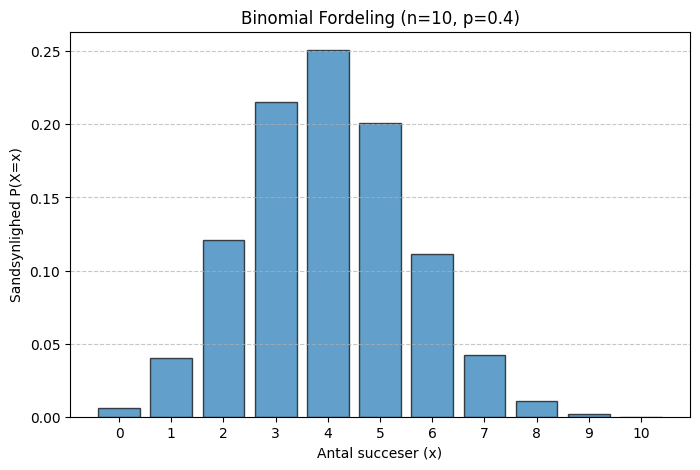

In [5]:
# Visualisering af binomialfordelingen
n, p = 10, 0.4
# Vi bruger her objekt-metoden, da det er nemmest til plots
X = binom(n, p)

x_values = np.arange(0, n + 1)
pmf_values = X.pmf(x_values)

plt.figure(figsize=(8, 5))
plt.bar(x_values, pmf_values, edgecolor='black', alpha=0.7)
plt.title(f'Binomial Fordeling (n={n}, p={p})')
plt.xlabel('Antal succeser (x)')
plt.ylabel('Sandsynlighed P(X=x)')
plt.xticks(x_values)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---

## 7. Simulation: Teori vs. Praksis

I statistikken bruger vi teori til at forudsige virkeligheden. Med simulation kan vi teste, om "loven om store tal" holder.
Her slår vi plat/krone 10 gange ($n=10$) og tæller antal kroner. Dette eksperiment gentager vi 10.000 gange.

Teoretisk middelværdi: 5.0
Empirisk middelværdi (fra sim): 4.9991


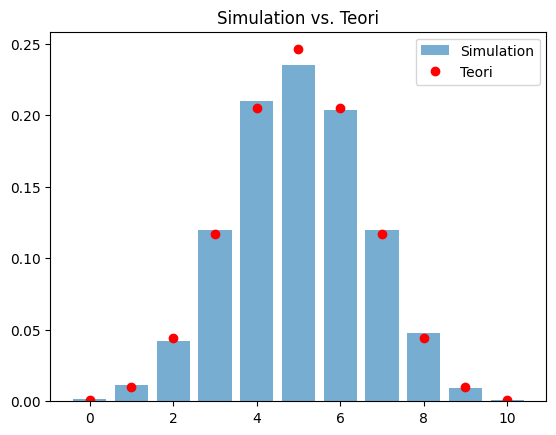

In [6]:
# Setup
n, p = 10, 0.5  # Fair mønt
simulations = 10000

# Kør simulation (generer 10.000 forsøg)
# rvs = Random Variates (tilfældige udfald)
# Kan også skrives som objekt: X.rvs(size=...)
sim_data = binom.rvs(n, p, size=simulations)

# Beregn empirisk middelværdi
empirisk_mean = np.mean(sim_data)
teoretisk_mean = n * p

print(f"Teoretisk middelværdi: {teoretisk_mean}")
print(f"Empirisk middelværdi (fra sim): {empirisk_mean}")

# Plot histogram af simulationen vs teoretisk kurve
plt.hist(
    sim_data,
    bins=np.arange(0, n + 2) - 0.5,
    density=True,
    rwidth=0.8,
    alpha=0.6,
    label='Simulation'
)
plt.plot(np.arange(0, n + 1), binom.pmf(np.arange(0, n + 1), n, p), 'ro', label='Teori')
plt.legend()
plt.title("Simulation vs. Teori")
plt.show()

### Hvad ser vi?

Når antallet af simulationer er højt (f.eks. 10.000), vil søjlerne (den empiriske data) næsten præcist matche de røde prikker (teorien). Det bekræfter, at vores model virker.

---

## 8. Opsummering – Hvad du nu skal kunne

Efter denne tutorial kan du:

- **Skelne mellem PMF og CDF** og vide, at lommeregnerens `binompdf`/`binomcdf` svarer til PMF/CDF.
- **Diskret uniform fordeling:** Beregne PMF, CDF, middelværdi, varians og standardafvigelse i både Python (`randint`) og WolframAlpha.
- **Bernoulli-fordeling:** Beregne PMF, middelværdi, varians og standardafvigelse i både Python (`bernoulli`) og WolframAlpha.
- **Binomialfordeling:** Beregne PMF ($P(X=k)$), CDF ($P(X \le k)$), interval-sandsynlighed ($P(a \le X \le b)$), middelværdi, varians og standardafvigelse i både Python (`binom`) og WolframAlpha.
- **Visualisere** en diskret fordeling (fx binomial-PMF) som søjlediagram i Python med Matplotlib.
- **Simulere** binomialforsøg i Python (`binom.rvs`) og sammenligne empirisk frekvens med den teoretiske fordeling.